In [1]:
# %% Cell 1: imports
import sys, torch, numpy as np
sys.path.append('..'); sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from backbones.backbones import get_resnet50, get_vit, get_clip, extract_all_features
from img_prep.make_subset import load_stl10
from img_prep.transforms import (to_common_224, resnet_normalize, vit_normalize, clip_normalize,
                                  patch_shuffle_transform, make_patch_permutations)
from evaluations.evaluate_bias import evaluate_head_with_preds, prediction_consistency, clip_zero_shot_batched
import open_clip, torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

set_seed(6304)
device = "cuda" if torch.cuda.is_available() else "cpu"
Path("../../report/figures").mkdir(parents=True, exist_ok=True)

In [2]:
# %% Cell 2: same subset, same clean reference
subset_ids = load_results("../results/subset_ids.json")
test_idx = subset_ids["test_subset_indices"]
clean_preds = load_results("../results/clean_predictions.json")["predictions"]
clean_baseline = load_results("../results/clean_baseline.json")["models"]

test_ds = load_stl10(split='test')
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

In [3]:
# %% Cell 3: generate the permutations ONCE and save them
perms = make_patch_permutations(len(test_idx), seed=6304)
save_results({"seed": 6304, "grid": "4x4", "permutations": perms},
             "../results/patch_permutations.json")
print(f"{len(perms)} permutations, first one: {perms[0]}")

# map each image's position in the subset to its own permutation
pos_of = {img_idx: pos for pos, img_idx in enumerate(test_idx)}

500 permutations, first one: [9, 4, 8, 1, 13, 0, 3, 15, 6, 12, 14, 7, 11, 10, 5, 2]


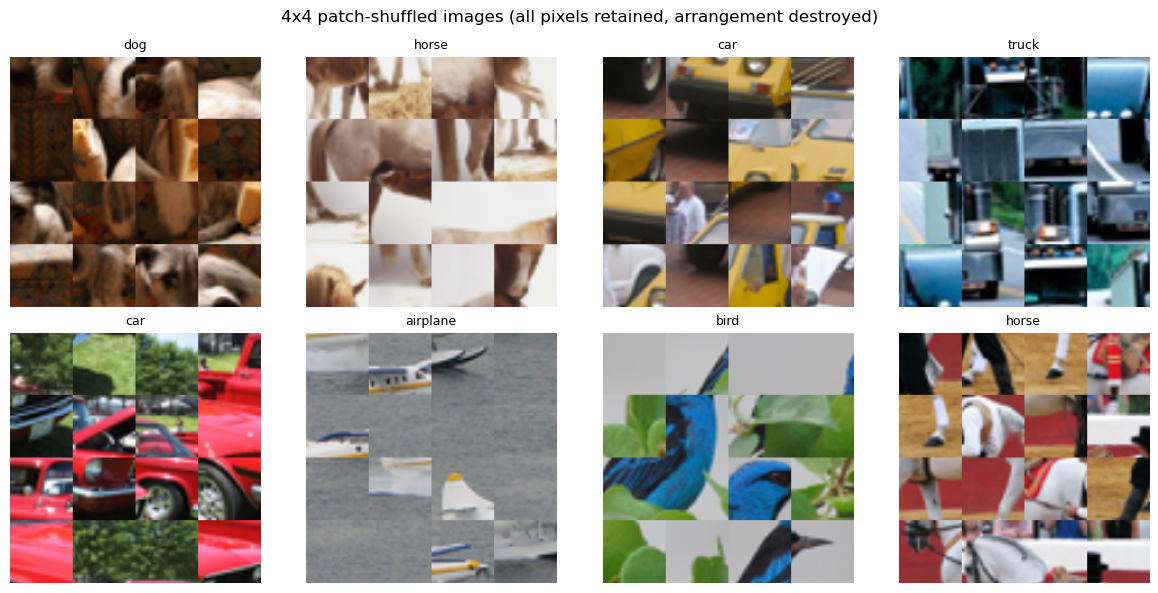

In [4]:
# %% Cell 4: look at a few before trusting anything
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for j, ax in enumerate(axes.flat):
    i = j * 37 % len(test_idx)
    clean = to_common_224(test_ds[test_idx[i]][0])
    shuf = patch_shuffle_transform(clean, perms[i])
    ax.imshow(shuf.permute(1, 2, 0).numpy()); ax.axis('off')
    ax.set_title(class_names[test_ds[test_idx[i]][1]], fontsize=9)
fig.suptitle("4x4 patch-shuffled images (all pixels retained, arrangement destroyed)", fontsize=12)
plt.tight_layout()
fig.savefig("../../report/figures/patch_shuffle_samples.png", dpi=200, bbox_inches='tight')
plt.show()

In [5]:
# %% Cell 5: backbones + saved heads
resnet, _ = get_resnet50(); vit, _ = get_vit(); clip_model, _ = get_clip()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

def load_head(name, in_dim):
    head = nn.Linear(in_dim, 10).to(device)
    head.load_state_dict(torch.load(f"../../datasets/cache/{name}_head.pth", map_location=device))
    head.eval(); return head

heads = {"resnet50": load_head("resnet50", 2048),
         "vit_b16": load_head("vit_b16", 768),
         "clip_head": load_head("clip_head", 512)}

backbones_info = [("resnet50", resnet, resnet_normalize, "resnet_or_vit"),
                  ("vit_b16", vit, vit_normalize, "resnet_or_vit"),
                  ("clip", clip_model, clip_normalize, "clip")]

In [6]:
# %% Cell 6: evaluate
# a counter-based closure, since extract_all_features feeds images in subset order
class ShuffleFn:
    """Applies image i's own permutation. Stateful because extract_all_features
    hands us one image at a time in order."""
    def __init__(self, perms): self.perms = perms; self.i = 0
    def reset(self): self.i = 0
    def __call__(self, x):
        out = patch_shuffle_transform(x, self.perms[self.i])
        self.i += 1
        return out

results = {"step": "patch_structure", "seed": 6304, "grid": "4x4", "models": {}}

for name, model, norm_fn, mtype in backbones_info:
    shuffler = ShuffleFn(perms); shuffler.reset()
    feats, labels = extract_all_features(model, test_ds, test_idx, norm_fn,
                                          model_type=mtype, intervention_fn=shuffler, device=device)
    if name == "clip":
        m_, p_ = evaluate_head_with_preds(heads["clip_head"], feats, labels)
        results["models"]["clip_head"] = {**m_,
            "acc_change": m_["top1_acc"] - clean_baseline["clip_head"]["top1_acc"],
            "consistency": prediction_consistency(np.array(clean_preds["clip_head"]), p_)}

        imgs = torch.stack([clip_normalize(patch_shuffle_transform(to_common_224(test_ds[idx][0]), perms[pos]))
                             for pos, idx in enumerate(test_idx)])
        zm, zp = clip_zero_shot_batched(clip_model, tokenizer, imgs, labels, class_names, device=device)
        results["models"]["clip_zeroshot"] = {**zm,
            "acc_change": zm["top1_acc"] - clean_baseline["clip_zeroshot"]["top1_acc"],
            "consistency": prediction_consistency(np.array(clean_preds["clip_zeroshot"]), zp)}
        del imgs; torch.cuda.empty_cache()
    else:
        m_, p_ = evaluate_head_with_preds(heads[name], feats, labels)
        results["models"][name] = {**m_,
            "acc_change": m_["top1_acc"] - clean_baseline[name]["top1_acc"],
            "consistency": prediction_consistency(np.array(clean_preds[name]), p_)}
    del feats; torch.cuda.empty_cache()

for m, r in results["models"].items():
    print(f"{m:<16} acc {r['top1_acc']:.3f} (Δ{r['acc_change']:+.3f})  "
          f"consistency {r['consistency']:.3f}  conf {r['mean_max_conf']:.3f}")

resnet50         acc 0.836 (Δ-0.116)  consistency 0.854  conf 0.730
vit_b16          acc 0.866 (Δ-0.098)  consistency 0.892  conf 0.703
clip_head        acc 0.792 (Δ-0.174)  consistency 0.804  conf 0.118
clip_zeroshot    acc 0.826 (Δ-0.138)  consistency 0.844  conf 0.803


In [7]:
# %% Cell 7: save
save_results(results, "../results/patch_structure.json")